# Regressão Linear com PyTorch - Dataset Salary Data

## Objetivos

Este exemplo utiliza regressão linear com um novo dataset vindo do Kaggle (https://www.kaggle.com/datasets/harlfoxem/housesalesprediction).

Utiliza-se:
- a função de perda MSE do PyTorch,
- treinamento dos parâmetros via gradiente descendente usando o otimizador.
- A rede é criada com uma camada nn.Linear()
- Divisão entre dataset de treinamento e validação

## Importação dos pacotes

In [5]:
%matplotlib inline
import torch
from torch import nn, optim
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(1234)

## Leitura dos dados

In [6]:
#!/bin/bash
!curl -L -o /content/housesalesprediction.zip\
  https://www.kaggle.com/api/v1/datasets/download/harlfoxem/housesalesprediction

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  779k  100  779k    0     0  2629k      0 --:--:-- --:--:-- --:--:-- 2629k


In [7]:
!unzip /content/housesalesprediction.zip

Archive:  /content/housesalesprediction.zip
  inflating: kc_house_data.csv       


In [8]:
# Load the dataset
df = pd.read_csv('kc_house_data.csv')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [10]:
X = df[['sqft_living']].values
y = df[['price']].values

### Normalização dos dados

In [11]:
# Normalize X
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

# Normalize y
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)

In [12]:
# Split the normalized dataset into training and validation sets (70/30 split)
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

# Convert numpy arrays to float tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_val_tensor shape:", X_val_tensor.shape)
print("y_val_tensor shape:", y_val_tensor.shape)

X_train_tensor shape: torch.Size([15129, 1])
y_train_tensor shape: torch.Size([15129, 1])
X_val_tensor shape: torch.Size([6484, 1])
y_val_tensor shape: torch.Size([6484, 1])


## Criação do modelo da rede

In [13]:
model = torch.nn.Linear(1, 1)

### Verificando a inicialização dos parâmetros

In [14]:
model.weight.data

tensor([[-0.9420]])

### Testando o predict da rede

In [15]:
model(torch.ones(5,1))

tensor([[-1.1382],
        [-1.1382],
        [-1.1382],
        [-1.1382],
        [-1.1382]], grad_fn=<AddmmBackward0>)

In [16]:
model(X_train_tensor[:3])

tensor([[-0.8117],
        [-0.4630],
        [-0.3091]], grad_fn=<AddmmBackward0>)

## Treinamento

### Definindo função de perda e otimizador

In [17]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.3)

### Laço de treinamento

In [18]:
def train_epoch(model, optimizer, criterion, X_train, y_train):
    model.train() # Set model to training mode
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward and optimize
    loss.backward()
    optimizer.step()

    return loss.item() # Return scalar loss value

In [19]:
def validate_epoch(model, criterion, X_val, y_val):
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculations
        outputs = model(X_val)
        loss = criterion(outputs, y_val)
    return loss.item() # Return scalar loss value

In [20]:
num_epochs = 120
w0_list = [] # Stores weights
w1_list = [] # Stores biases
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training step
    train_loss = train_epoch(model, optimizer, criterion, X_train_tensor, y_train_tensor)
    train_losses.append(train_loss)

    # Validation step
    val_loss = validate_epoch(model, criterion, X_val_tensor, y_val_tensor)
    val_losses.append(val_loss)

    # Store weights and biases for plotting later (w0 -> weight, w1 -> bias)
    w0_list.append(model.weight.data[0][0].item())
    if model.bias is not None:
        w1_list.append(model.bias.data[0].item())
    else:
        w1_list.append(0.0) # Append 0 if no bias

    # verbose
    if (epoch + 1) % 20 == 0:
        print(f'Epoch[{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

Epoch[20/120], Train Loss: 0.487578, Val Loss: 0.552843
Epoch[40/120], Train Loss: 0.487578, Val Loss: 0.552843
Epoch[60/120], Train Loss: 0.487578, Val Loss: 0.552843
Epoch[80/120], Train Loss: 0.487578, Val Loss: 0.552843
Epoch[100/120], Train Loss: 0.487578, Val Loss: 0.552843
Epoch[120/120], Train Loss: 0.487578, Val Loss: 0.552843


## Avaliação

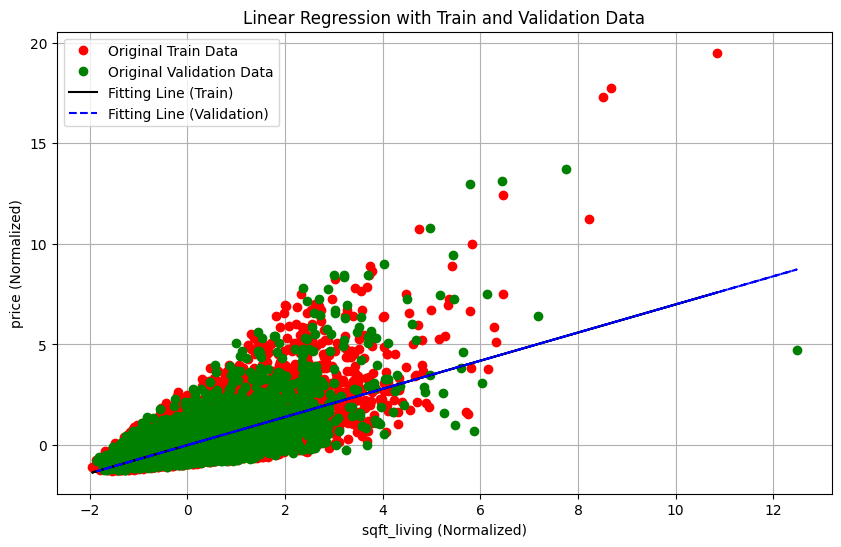

In [21]:
y_pred_train = model(X_train_tensor)
y_pred_val = model(X_val_tensor)

plt.figure(figsize=(10, 6))

# Plot original training data
plt.plot(X_train_tensor.numpy(), y_train_tensor.numpy(), 'ro', label='Original Train Data')

# Plot original validation data
plt.plot(X_val_tensor.numpy(), y_val_tensor.numpy(), 'go', label='Original Validation Data')

# Plot fitting line for training data
plt.plot(X_train_tensor.numpy(), y_pred_train.data.numpy(), 'k-', label='Fitting Line (Train)')

# Plot fitting line for validation data
plt.plot(X_val_tensor.numpy(), y_pred_val.data.numpy(), 'b--', label='Fitting Line (Validation)')

plt.xlabel('sqft_living (Normalized)')
plt.ylabel('price (Normalized)')
plt.title('Linear Regression with Train and Validation Data')
plt.legend()
plt.grid(True)
plt.show()

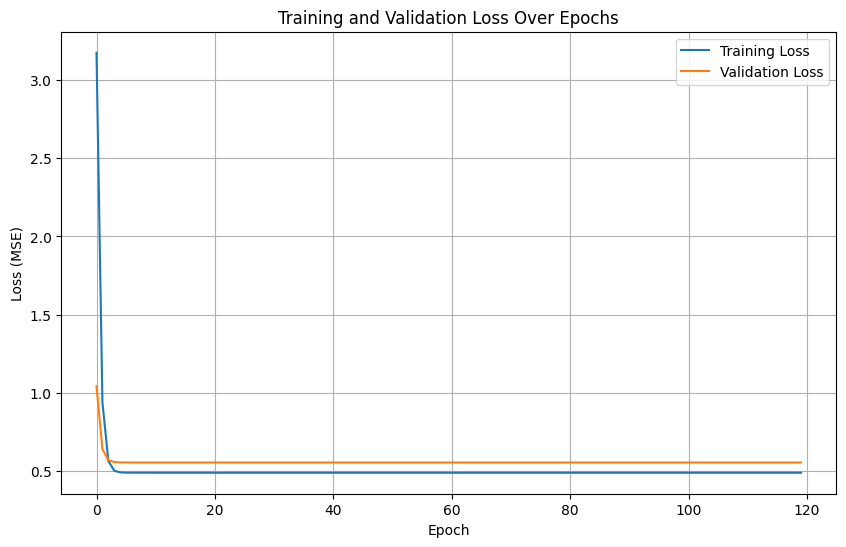

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
X = df[['sqft_living', 'bathrooms', 'bedrooms']].values
y = df[['price']].values

# Normalize X
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

# Normalize y
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)

# Split the normalized dataset into training and validation sets (70/30 split)
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

# Convert numpy arrays to float tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_val_tensor shape:", X_val_tensor.shape)
print("y_val_tensor shape:", y_val_tensor.shape)


X_train_tensor shape: torch.Size([15129, 3])
y_train_tensor shape: torch.Size([15129, 1])
X_val_tensor shape: torch.Size([6484, 3])
y_val_tensor shape: torch.Size([6484, 1])


In [26]:
num_epochs = 120
w0_feature1_list = [] # Stores weights for feature 1
w0_feature2_list = [] # Stores weights for feature 2
w0_feature3_list = [] # Stores weights for feature 3
w1_list = [] # Stores biases
train_losses = []
val_losses = []

# Re-initialize model to ensure fresh training
model = torch.nn.Linear(X_train_tensor.shape[1], 1)
optimizer = optim.SGD(model.parameters(), lr=0.3)
criterion = nn.MSELoss()

for epoch in range(num_epochs):
    # Training step
    train_loss = train_epoch(model, optimizer, criterion, X_train_tensor, y_train_tensor)
    train_losses.append(train_loss)

    # Validation step
    val_loss = validate_epoch(model, criterion, X_val_tensor, y_val_tensor)
    val_losses.append(val_loss)

    # Store weights and biases for plotting later (w0 -> weight, w1 -> bias)
    w0_feature1_list.append(model.weight.data[0][0].item())
    w0_feature2_list.append(model.weight.data[0][1].item())
    w0_feature3_list.append(model.weight.data[0][2].item())
    if model.bias is not None:
        w1_list.append(model.bias.data[0].item())
    else:
        w1_list.append(0.0) # Append 0 if no bias

    # verbose
    if (epoch + 1) % 20 == 0:
        print(f'Epoch[{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

Epoch[20/120], Train Loss: 0.474497, Val Loss: 0.538903
Epoch[40/120], Train Loss: 0.473902, Val Loss: 0.537939
Epoch[60/120], Train Loss: 0.473901, Val Loss: 0.537915
Epoch[80/120], Train Loss: 0.473901, Val Loss: 0.537914
Epoch[100/120], Train Loss: 0.473901, Val Loss: 0.537914
Epoch[120/120], Train Loss: 0.473901, Val Loss: 0.537914


In [28]:
X_train_bias = np.hstack((np.ones((X_train_tensor.shape[0], 1)), X_train_tensor.numpy()))
X_train_bias_tensor = torch.tensor(X_train_bias, dtype=torch.float32)

print("Shape of X_train_bias_tensor:", X_train_bias_tensor.shape)

Shape of X_train_bias_tensor: torch.Size([15129, 4])


In [33]:
x_bias = X_train_bias_tensor
y = y_train_tensor
x_bias_t = torch.t(x_bias)
w_opt = (torch.inverse(x_bias_t.mm(x_bias)).mm(x_bias_t)).mm(y)

w_bias_opt = w_opt[0].item()
w_sqft_living_opt = w_opt[1].item()
w_bathrooms_opt = w_opt[2].item()
w_bedrooms_opt = w_opt[3].item()

print(f"Analytical Solution (Bias, sqft_living, bathrooms, bedrooms):\nBias: {w_bias_opt:.4f}\nsqft_living: {w_sqft_living_opt:.4f}\nbathrooms: {w_bathrooms_opt:.4f}\nbedrooms: {w_bedrooms_opt:.4f}")

Analytical Solution (Bias, sqft_living, bathrooms, bedrooms):
Bias: -0.0021
sqft_living: 0.7669
bathrooms: 0.0202
bedrooms: -0.1435


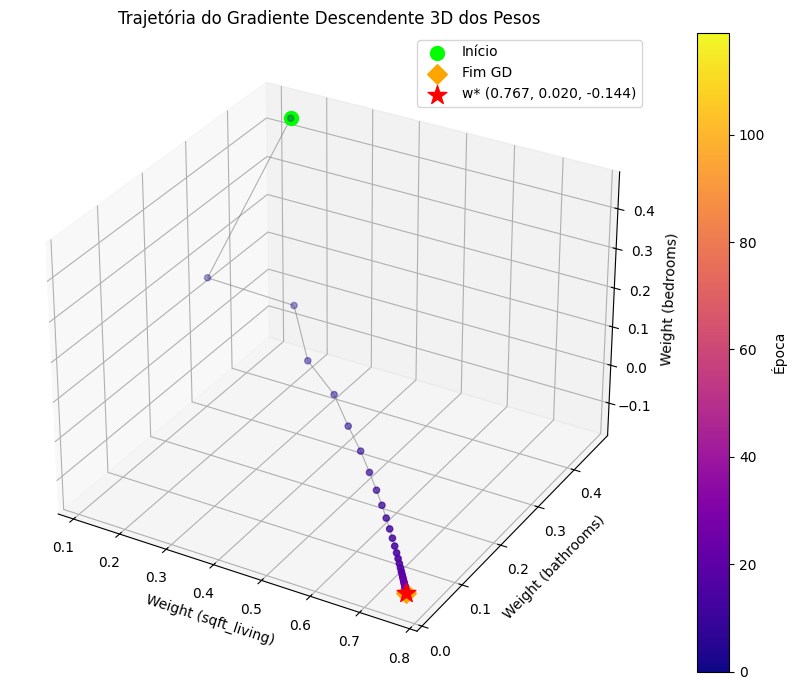

In [34]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Trajetória - using the three feature weights lists
# Ensure all lists have the same length for plotting (they should be if appended in the same loop)
min_len = min(len(w0_feature1_list), len(w0_feature2_list), len(w0_feature3_list))
plot_w0_f1 = w0_feature1_list[:min_len]
plot_w0_f2 = w0_feature2_list[:min_len]
plot_w0_f3 = w0_feature3_list[:min_len]

sc = ax.scatter(plot_w0_f1, plot_w0_f2, plot_w0_f3,
                c=range(min_len), cmap='plasma',
                s=20, zorder=3)
ax.plot(plot_w0_f1, plot_w0_f2, plot_w0_f3,
        color='gray', linewidth=0.8, alpha=0.6)

# Início e fim
ax.scatter(plot_w0_f1[0], plot_w0_f2[0], plot_w0_f3[0],
           color='lime', s=100, zorder=5, label='Início')
ax.scatter(plot_w0_f1[-1], plot_w0_f2[-1], plot_w0_f3[-1],
           color='orange', s=100, marker='D', zorder=5, label='Fim GD')

# Solução analítica
ax.scatter(w_sqft_living_opt, w_bathrooms_opt, w_bedrooms_opt,
          color='red', s=200, marker='*', zorder=6,
          label=f'w* ({w_sqft_living_opt:.3f}, {w_bathrooms_opt:.3f}, {w_bedrooms_opt:.3f})')

plt.colorbar(sc, ax=ax, label='Época')
ax.set_xlabel('Weight (sqft_living)')
ax.set_ylabel('Weight (bathrooms)')
ax.set_zlabel('Weight (bedrooms)')
ax.set_title('Trajetória do Gradiente Descendente 3D dos Pesos')
ax.legend()

plt.tight_layout()
plt.show()